In [73]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

In [74]:
test = json.loads(open('../info.json', 'r', encoding='utf-8').read()).get('test') 
test

1

# DADOS MEASURE

,ay,roll,wz,tmp,wy,pitch,e,wx,az,time,ax,yaw
0,50081,27,-5728,56.374515,2509,14,0.288,5034,963254,0.0,23234,10741
1,-21533,-8,-7225,56.271033,-3537,16,0.288,9200,928382,0.1,23907,10808
2,-56109,-23,415,55.906699,3362,-32,0.288,3411,1018579,0.2,76446,10826
3,-9627,10,-3571,56.069579,5038,-8,0.288,-5902,1007587,0.3,-19513,10853
4,-38180,-10,5010,56.799013,-5453,4,0.288,-3106,953893,0.4,73539,10795
...,...,...,...,...,...,...,...,...,...,...,...,...
13345,-121233,8,45,57.293121,-5292,-13,0.288,1630,990240,1334.5,15863,10877
13346,8011,-1,-6165,56.295740,-2858,23,0.288,-10375,1044513,1334.6,-27131,10800
13347,-11671,19,5234,56.396618,-3852,-10,0.288,3563,985554,1334.7,11791,10813
13348,59414,-23,-4711,55.548113,-3608,29,0.288,272,969029,1334.8,-16257,10783


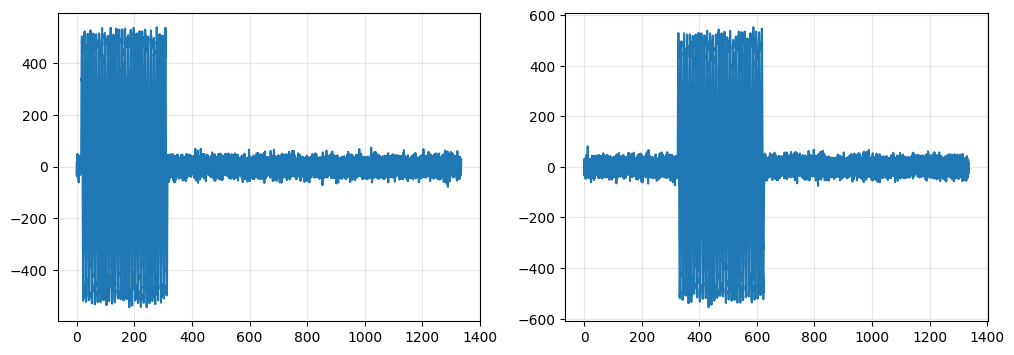

In [75]:
df_target = pd.read_csv(f'files/test{test}/target/data.csv')
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df_target.time, df_target.pitch); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
plt.plot(df_target.time, df_target.roll); plt.grid(alpha=.3)
df_target

# DADOS KONGSBERG

,ay,roll,wz,tmp,wy,pitch,e,wx,az,time,ax,yaw
0,-1699,-3,-1190,56.142495,-656,-2,0.288,642,986239,0.0,5688,10852
1,1741,2,312,56.135773,73,-6,0.288,781,998974,0.1,-1227,10845
2,-9164,1,2111,56.749792,739,2,0.288,-293,1010684,0.2,162,10773
3,-5196,1,2998,56.534775,-371,2,0.288,2043,994563,0.3,-164,10713
4,-14703,0,-351,56.908744,-607,2,0.288,146,1008984,0.4,10418,10895
...,...,...,...,...,...,...,...,...,...,...,...,...
13345,17177,-3,-785,57.236518,566,-1,0.288,813,1001741,1334.5,-11945,10808
13346,3943,7,717,56.155693,-1310,-4,0.288,373,989489,1334.6,9015,10894
13347,24987,0,-141,56.649703,1798,2,0.288,247,1009089,1334.7,-2848,10886
13348,-416,-1,-514,56.285961,331,-2,0.288,779,978956,1334.8,-4539,10863


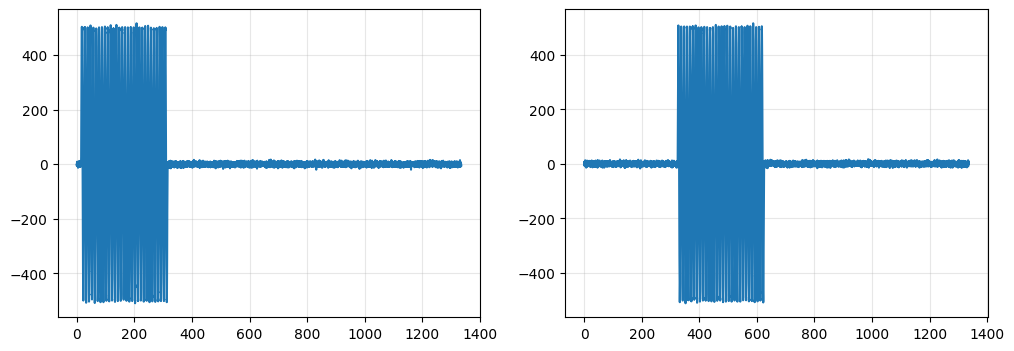

In [76]:
df_mru = pd.read_csv(f'files/test{test}/mru/data.csv')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df_mru.time, df_mru.pitch); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
plt.plot(df_mru.time, df_mru.roll); plt.grid(alpha=.3)
df_mru

# DADOS MESA

,ay,roll,wz,tmp,wy,pitch,e,wx,az,time,ax,yaw
0,0,0,0,56.366168,0,0,0.288,0,1000000,0.0,0,10790
1,0,0,0,56.023592,0,0,0.288,0,1000000,0.1,0,10885
2,0,0,0,56.833742,0,0,0.288,0,1000000,0.2,0,10711
3,0,0,0,56.836007,0,0,0.288,0,1000000,0.3,0,10753
4,0,0,0,57.207612,0,0,0.288,0,1000000,0.4,0,10831
...,...,...,...,...,...,...,...,...,...,...,...,...
13345,0,0,0,55.862601,0,0,0.288,0,1000000,1334.5,0,10861
13346,0,0,0,56.744240,0,0,0.288,0,1000000,1334.6,0,10822
13347,0,0,0,57.594996,0,0,0.288,0,1000000,1334.7,0,10804
13348,0,0,0,56.694395,0,0,0.288,0,1000000,1334.8,0,10838


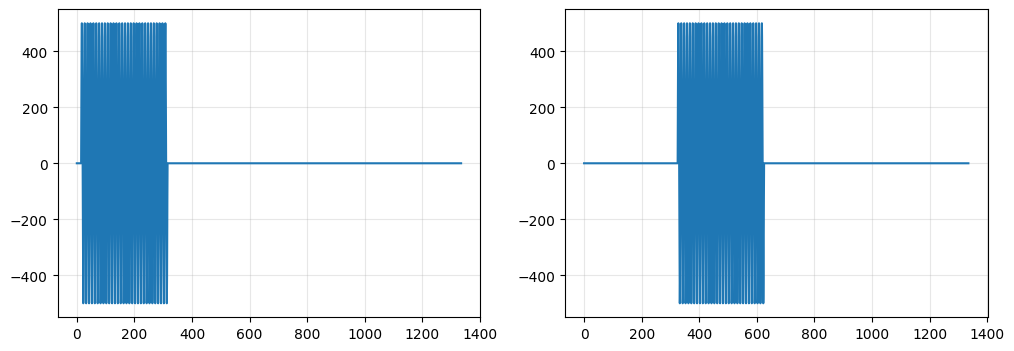

In [77]:
df_ref = pd.read_csv(f'files/test{test}/reference/data.csv')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df_ref.time, df_ref.pitch); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
plt.plot(df_ref.time, df_ref.roll); plt.grid(alpha=.3)
df_ref

# JUNTANDO TABELAS

In [78]:
df_target = df_target.rename(columns={col: 'target_' + col for col in df_target.columns if col not in ['time']})
df_target.head()

,target_ay,target_roll,target_wz,target_tmp,target_wy,target_pitch,target_e,target_wx,target_az,time,target_ax,target_yaw
0,50081,27,-5728,56.374515,2509,14,0.288,5034,963254,0.0,23234,10741
1,-21533,-8,-7225,56.271033,-3537,16,0.288,9200,928382,0.1,23907,10808
2,-56109,-23,415,55.906699,3362,-32,0.288,3411,1018579,0.2,76446,10826
3,-9627,10,-3571,56.069579,5038,-8,0.288,-5902,1007587,0.3,-19513,10853
4,-38180,-10,5010,56.799013,-5453,4,0.288,-3106,953893,0.4,73539,10795


In [79]:
df_mru = df_mru.rename(columns={col: 'mru_' + col for col in df_mru.columns if col not in ['time']})
df_mru.head()

,mru_ay,mru_roll,mru_wz,mru_tmp,mru_wy,mru_pitch,mru_e,mru_wx,mru_az,time,mru_ax,mru_yaw
0,-1699,-3,-1190,56.142495,-656,-2,0.288,642,986239,0.0,5688,10852
1,1741,2,312,56.135773,73,-6,0.288,781,998974,0.1,-1227,10845
2,-9164,1,2111,56.749792,739,2,0.288,-293,1010684,0.2,162,10773
3,-5196,1,2998,56.534775,-371,2,0.288,2043,994563,0.3,-164,10713
4,-14703,0,-351,56.908744,-607,2,0.288,146,1008984,0.4,10418,10895


In [80]:
df_ref = df_ref.rename(columns={col: 'ref_' + col for col in df_ref.columns if col not in ['time']})
df_ref.head()

,ref_ay,ref_roll,ref_wz,ref_tmp,ref_wy,ref_pitch,ref_e,ref_wx,ref_az,time,ref_ax,ref_yaw
0,0,0,0,56.366168,0,0,0.288,0,1000000,0.0,0,10790
1,0,0,0,56.023592,0,0,0.288,0,1000000,0.1,0,10885
2,0,0,0,56.833742,0,0,0.288,0,1000000,0.2,0,10711
3,0,0,0,56.836007,0,0,0.288,0,1000000,0.3,0,10753
4,0,0,0,57.207612,0,0,0.288,0,1000000,0.4,0,10831


In [81]:
df = pd.merge_asof(df_target, df_ref, on='time', direction='nearest')
df = pd.merge_asof(df, df_mru, on='time', direction='nearest')
df

,target_ay,target_roll,target_wz,target_tmp,target_wy,target_pitch,target_e,target_wx,target_az,time,target_ax,target_yaw,ref_ay,ref_roll,ref_wz,ref_tmp,ref_wy,ref_pitch,ref_e,ref_wx,ref_az,ref_ax,ref_yaw,mru_ay,mru_roll,mru_wz,mru_tmp,mru_wy,mru_pitch,mru_e,mru_wx,mru_az,mru_ax,mru_yaw
0,50081,27,-5728,56.374515,2509,14,0.288,5034,963254,0.0,23234,10741,0,0,0,56.366168,0,0,0.288,0,1000000,0,10790,-1699,-3,-1190,56.142495,-656,-2,0.288,642,986239,5688,10852
1,-21533,-8,-7225,56.271033,-3537,16,0.288,9200,928382,0.1,23907,10808,0,0,0,56.023592,0,0,0.288,0,1000000,0,10885,1741,2,312,56.135773,73,-6,0.288,781,998974,-1227,10845
2,-56109,-23,415,55.906699,3362,-32,0.288,3411,1018579,0.2,76446,10826,0,0,0,56.833742,0,0,0.288,0,1000000,0,10711,-9164,1,2111,56.749792,739,2,0.288,-293,1010684,162,10773
3,-9627,10,-3571,56.069579,5038,-8,0.288,-5902,1007587,0.3,-19513,10853,0,0,0,56.836007,0,0,0.288,0,1000000,0,10753,-5196,1,2998,56.534775,-371,2,0.288,2043,994563,-164,10713
4,-38180,-10,5010,56.799013,-5453,4,0.288,-3106,953893,0.4,73539,10795,0,0,0,57.207612,0,0,0.288,0,1000000,0,10831,-14703,0,-351,56.908744,-607,2,0.288,146,1008984,10418,10895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13345,-121233,8,45,57.293121,-5292,-13,0.288,1630,990240,1334.5,15863,10877,0,0,0,55.862601,0,0,0.288,0,1000000,0,10861,17177,-3,-785,57.236518,566,-1,0.288,813,1001741,-11945,10808
13346,8011,-1,-6165,56.295740,-2858,23,0.288,-10375,1044513,1334.6,-27131,10800,0,0,0,56.744240,0,0,0.288,0,1000000,0,10822,3943,7,717,56.155693,-1310,-4,0.288,373,989489,9015,10894
13347,-11671,19,5234,56.396618,-3852,-10,0.288,3563,985554,1334.7,11791,10813,0,0,0,57.594996,0,0,0.288,0,1000000,0,10804,24987,0,-141,56.649703,1798,2,0.288,247,1009089,-2848,10886
13348,59414,-23,-4711,55.548113,-3608,29,0.288,272,969029,1334.8,-16257,10783,0,0,0,56.694395,0,0,0.288,0,1000000,0,10838,-416,-1,-514,56.285961,331,-2,0.288,779,978956,-4539,10863


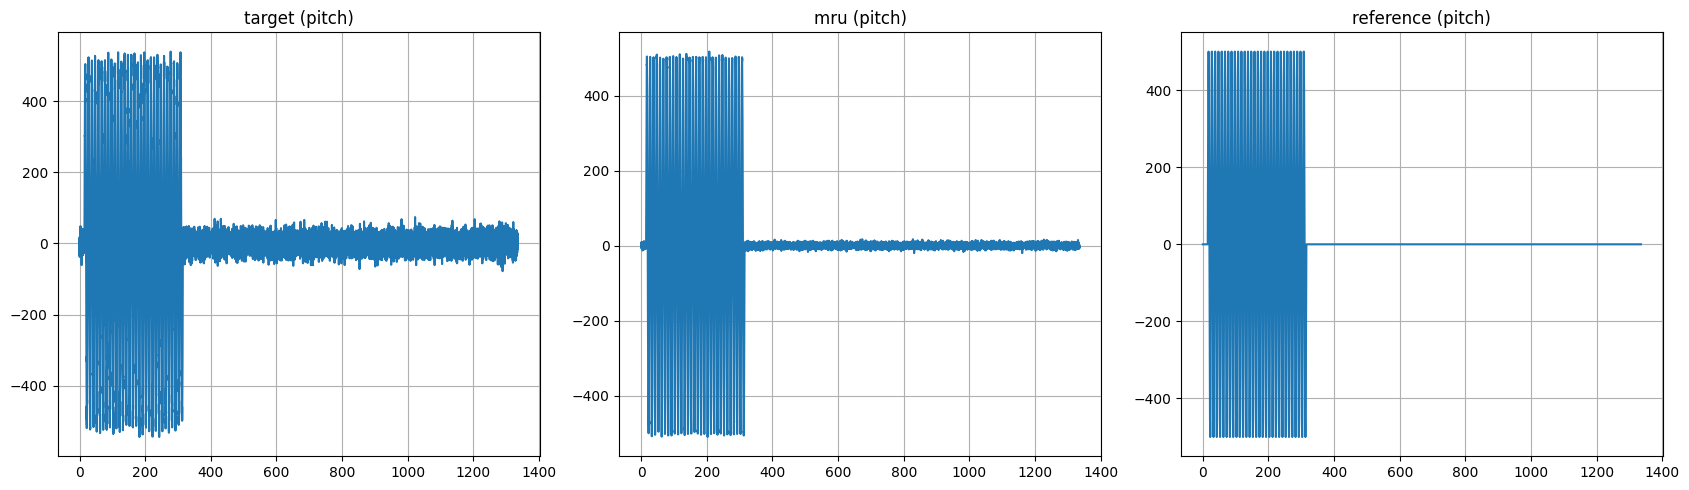

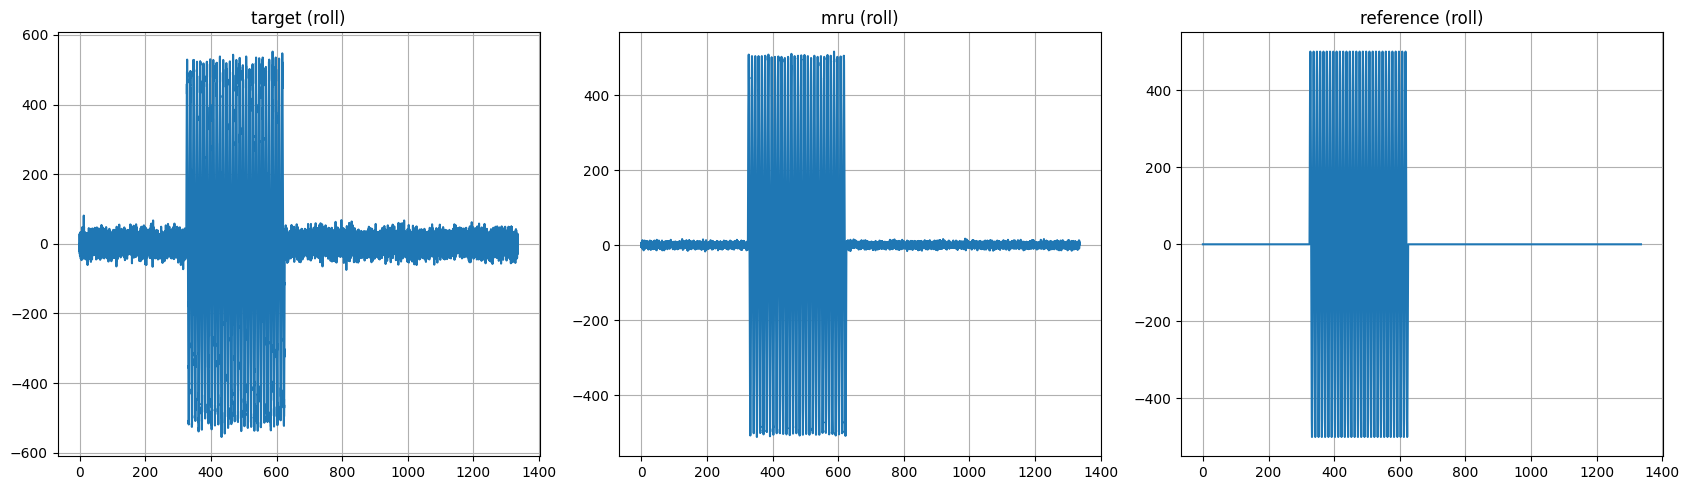

In [82]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll']:
    compareAxis({
        f'target ({var})':  df[f'target_{var}'], 
        f'mru ({var})': df[f'mru_{var}'],
        f'reference ({var})': df[f'ref_{var}'],
    }, time=df.time, figsize=(17, 5))

# ENCONTRANDO CATEGORIAS
- status pode ser = 'none' (nenhum/estabilizando), 'pitch' (variando pitch), 'roll' (variando roll), 'static' (parado)
- Implementação da detecção pelos dados utilizando os intervalos com folgas de 10s:

In [ ]:
conditions = [
    (df['time'] >= 15) & (df['time'] < 315),  # 300s variando pitch
    (df['time'] >= 325) & (df['time'] < 625), # 300s variando roll
    (df['time'] >= 635)                       # estático (parado)
]

choices = ['pitch', 'roll', 'static']
df['status'] = np.select(conditions, choices, default='none')
df['status'].value_counts()

status
static    7000
pitch     3000
roll      3000
none       350
Name: count, dtype: int64

# SALVANDO DADOS

In [84]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)